# 📊 Fintra-AI: Exploratory Data Analysis & Schema Normalization (01_eda.ipynb)

### 🎯 Objective
This notebook performs **Exploratory Data Analysis (EDA)** on raw financial transaction records. It validates input schemas, cleans messy financial logs, unifies heterogeneous data sources into canonical Fintra-AI schemas, and assesses baseline data distributions.

---
### 🛠️ Key Pipeline Stages:
1. **Environment Setup & Imports**
2. **Dataset Discovery & Ingestion**
3. **Data Quality & Integrity Validation**
4. **Data Cleaning & Schema Harmonization**
5. **Basic Statistical Profile & Distribution Exploration**
6. **Key Observations & Next Steps**


In [1]:
# 1. Imports and System Path Configuration
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to sys.path to enable imports from ml.analysis
sys.path.insert(0, os.path.abspath(".."))

from ml.analysis.data_loader import (
    load_project_dataset,
    validate_and_clean_dataframe,
    generate_sample_financial_dataset,
    CANONICAL_COLUMNS,
    ROADMAP_CATEGORIES
)

# Visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

print("[OK] Successfully loaded core analytics modules.")


[OK] Successfully loaded core analytics modules.


## 2. Ingestion & Multi-Source Loading

In Fintra-AI, transaction data originates from multiple source formats (e.g. mobile banking feeds, CSV statements, household expense ledgers).
We load the raw datasets and apply canonical schema transformation.


In [2]:
# 2. Load unified transaction records
df = load_project_dataset(include_raw_sources=True)

if df.empty:
    print("[warn] No existing CSV files found at standard paths. Generating realistic synthetic dataset for analysis...")
    df = generate_sample_financial_dataset(n_records=500, seed=42)

print(f"Total Loaded Transactions: {len(df):,}")
print(f"Canonical Columns: {list(df.columns)}")
df.head(8)


Total Loaded Transactions: 10,440
Canonical Columns: ['date', 'amount', 'type', 'category', 'merchant', 'description', 'account_type', 'source']


,date,amount,type,category,merchant,description,account_type,source
0,2025-01-01,80349.08,EXPENSE,shopping,Samsung Store,Transaction at Samsung Store,Current,personal_finance_dataset_8000_extended.csv
1,2025-01-01,863.68,EXPENSE,transport,BMTC,Transaction at BMTC,Salary,personal_finance_dataset_8000_extended.csv
2,2025-01-01,17662.65,EXPENSE,healthcare,CloudNine,Transaction at CloudNine,Savings,personal_finance_dataset_8000_extended.csv
3,2025-01-01,4198.03,EXPENSE,food,JioMart,Transaction at JioMart,Credit Card,personal_finance_dataset_8000_extended.csv
4,2025-01-01,214.49,EXPENSE,transport,Uber,Transaction at Uber,Salary,personal_finance_dataset_8000_extended.csv
5,2025-01-01,312.62,EXPENSE,entertainment,Aha,Transaction at Aha,Credit Card,personal_finance_dataset_8000_extended.csv
6,2025-01-01,1315.41,EXPENSE,bills,Vodafone Idea,Transaction at Vodafone Idea,Credit Card,personal_finance_dataset_8000_extended.csv
7,2025-01-01,3025.08,EXPENSE,food,More Supermarket,Transaction at More Supermarket,Salary,personal_finance_dataset_8000_extended.csv


## 3. Data Integrity & Completeness Audit

Before analyzing spending patterns, we systematically inspect:
* Missing values (NaNs in dates, amounts, categories)
* Data types and date validity
* Type breakdown (`INCOME` vs `EXPENSE`)
* Category representation across Fintra-AI's canonical roadmap categories


In [3]:
# 3. Data Quality Report
print("--- Missing Values Audit ---")
print(df.isnull().sum())

print("\n--- Transaction Type Distribution ---")
print(df["type"].value_counts(dropna=False))

print("\n--- Date Range Span ---")
valid_dates = df.dropna(subset=["date"])
print(f"Earliest Date: {valid_dates['date'].min()}")
print(f"Latest Date:   {valid_dates['date'].max()}")
print(f"Total Span:    {(valid_dates['date'].max() - valid_dates['date'].min()).days} days")

print("\n--- Category Distribution ---")
print(df["category"].value_counts())


--- Missing Values Audit ---
date            1
amount          0
type            0
category        0
merchant        0
description     0
account_type    0
source          0
dtype: int64

--- Transaction Type Distribution ---
type
EXPENSE    10315
INCOME       125
Name: count, dtype: int64

--- Date Range Span ---
Earliest Date: 2015-01-01 00:00:00
Latest Date:   2025-12-31 00:00:00
Total Span:    4017 days

--- Category Distribution ---
category
food             2511
shopping         2504
transport        1872
entertainment     995
bills             993
healthcare        898
other             503
investment        101
salary             43
education          20
Name: count, dtype: int64


## 4. Amount Statistics & Distribution Checks

Understanding transaction amount distributions is essential for setting spending limits and outlier thresholds.


In [4]:
# 4. Statistical Summary of Transaction Amounts
desc = df.groupby("type")["amount"].describe().round(2)
desc


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
EXPENSE,10315.0,10095.53,23951.59,0.0,495.23,1773.68,7532.16,250000.0
INCOME,125.0,24339.18,30031.32,2.0,25.00,2000.00,51562.45,113376.0


C:\Users\manya\AppData\Local\Temp\ipykernel_14016\3200829598.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=expenses, y="category", order=cat_order, ax=axes[1], palette="viridis")


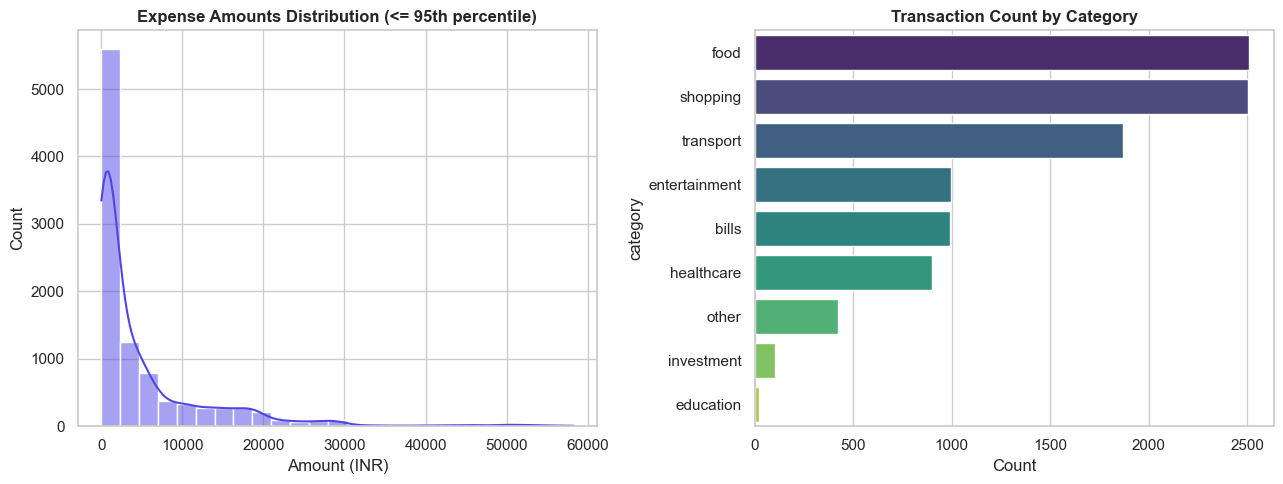

In [5]:
# 5. Quick EDA Visual Check
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution of expense amounts
expenses = df[df["type"] == "EXPENSE"]
upper_cutoff = expenses["amount"].quantile(0.95)
clipped = expenses[expenses["amount"] <= upper_cutoff]["amount"]

sns.histplot(clipped, kde=True, ax=axes[0], color="#4F46E5", bins=25)
axes[0].set_title("Expense Amounts Distribution (<= 95th percentile)", fontweight="bold")
axes[0].set_xlabel("Amount (INR)")

# Category frequency
cat_order = expenses["category"].value_counts().index
sns.countplot(data=expenses, y="category", order=cat_order, ax=axes[1], palette="viridis")
axes[1].set_title("Transaction Count by Category", fontweight="bold")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()


## 5. Summary & Exploratory Findings
- **Data Cleanliness**: Dates and amounts are normalized into standard formats (`pd.Timestamp` and positive numeric floats).
- **Categories**: Transactions map cleanly into Fintra-AI canonical categories (`food`, `shopping`, `transport`, `bills`, `entertainment`, `healthcare`, `education`, etc.).
- **Next Steps**: Proceed to [`02_financial_analysis.ipynb`](file:///notebooks/02_financial_analysis.ipynb) for in-depth metrics on transaction volume, expenses, income stability, and 50/30/20 budget adherence.
